##### Libraries

In [1]:

import json
import requests
import os
import pandas as pd
import logging
import requests
import Agent_memory 
import Agent_detection
import lancedb
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import Optional, Literal, Dict, Literal, List
from dotenv import load_dotenv
import time
from openai._exceptions import BadRequestError
import smtplib
from email.message import EmailMessage
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import utils.ReportFiles as rf
warnings.filterwarnings("ignore")


##### General parameters and configurations

In [2]:
report_metrics_file = "report_metrics.csv"
reports_dir = "reports"
memory_file = "memory.json"
tools_schema = "tools_schema.json"

header = ['Datetime_request', 'Input_prompt', 'Total_time_request',  'Step', 'Anomaly_detected' , 'Tool', 'Success', 'Latency', 'Confidence', 'Tokens', 'Calls_API', 'Response']

# Set up logging configuration
logging.basicConfig(
    filename="application.log",
    filemode="w",
    level=logging.INFO,
    format="\n%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True    
    
)
logger = logging.getLogger(__name__)

# Setup LLM 
# Load environment variables
load_dotenv()
# Initialize OpenAI client
client = OpenAI()
model = "gpt-4o-mini"
model_tools = "gpt-4"


##### Tools schema load

In [3]:
# Load the tools structure from file
with open(tools_schema, "r", encoding="utf-8") as f:
    tools = json.load(f)


#### Memory functions 

In [4]:
def get_agent_memory():
    """Load the agent memory from the file and return the recent messages."""
    try:    
        memory = Agent_memory.load_memory_from_file(memory_file)  
        return memory.get_recent_messages()
    except Exception as e:
        logger.error(f"Error loading the memory: {e}")
        return None

def clean_agent_memory():
    """Clear the agent memory file."""
    Agent_memory.clear_memory_file(memory_file)
    return 

# Create the memory file
memory = Agent_memory.Memory()
Agent_memory.save_memory_to_file(memory_file, memory)

##### Functions/Tools called by the Agent

In [5]:
def _convert_dataframe_to_json(df, message_if_none):
    """Convert a DataFrame to JSON format."""
    if df is None or df.empty:
        return {"temperature": 0.0, "response": message_if_none}
    return df.to_json(orient='records')

def detect_anomaly_by_dates(start_date, end_date):
    """Get all anomalies in a date range."""
    try:
        df, anomaly_type = Agent_detection.detect_all_anomalies_dates(start_date, end_date)
        json_str = _convert_dataframe_to_json(df, "No records found in these dates.")
        return json_str, anomaly_type
    except Exception as e:
        logger.error(f"Error in detect_anomaly_by_dates: {e}")
        return {"temperature": 0.0, "response": "Error retrieving anomalies"}, None

def detect_anomaly_by_dates_by_parameter(start_date, end_date, parameter):
    """Get anomalies by parameter within a date range."""
    try:
        df, anomaly_type = Agent_detection.detect_all_anomalies_dates_by_parameter(start_date, end_date, parameter)
        json_str = _convert_dataframe_to_json(df, "No records found in these dates.")
        return json_str, anomaly_type
    except Exception as e:
        logger.error(f"Error in detect_anomaly_by_dates_by_parameter: {e}")
        return {"temperature": 0.0, "response": "Error retrieving anomalies"}, None

def identify_anomaly_by_id(type_anomaly):
    """Look up anomaly type in glossary."""
    try:
        df = pd.read_csv('anomalies_glossary.csv')
        filtered_df = df.loc[df['Type of anomaly'] == type_anomaly, ['Description', 'Relevance', 'Severity']]
        return _convert_dataframe_to_json(filtered_df, "No description found for this anomaly type.")
    except Exception as e:
        logger.error(f"Error in identify_anomaly_by_id: {e}")
        return {"temperature": 0.0, "response": "Error accessing glossary"}

def send_email_notification(to: str, subject: str, body: str):
    """Send an email notification."""
    sender_email = os.getenv("SENDER_EMAIL")
    password = os.getenv("SENDER_PASSWORD")
    to = os.getenv("RECEIVER_EMAIL")

    msg = EmailMessage()
    msg["From"] = sender_email
    msg["To"] = to
    msg["Subject"] = subject
    msg.set_content(body)

    try:
        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as smtp:
            smtp.login(sender_email, password)
            smtp.send_message(msg)
        logger.info("Email sent successfully")
        return {"action": "Email sent", "to": to, "subject": subject, "body": body}
    except Exception as e:
        logger.error(f"Error sending email: {e}")
        return {"error": str(e), "action": "Email failed"}

def call_API(endpoint: str, method: str, title: str, body: str, userId: int):
    """Call an external API."""
    payload = {
        "title": title,
        "body": body,
        "userId": userId
    }

    try:
        if method.upper() == "POST":
            response = requests.post(endpoint, json=payload)
        elif method.upper() == "GET":
            response = requests.get(endpoint, params=payload)
        else:
            raise ValueError("Unsupported method: use 'GET' or 'POST'")

        response.raise_for_status()
        logger.info("API called successfully")
        return {
            "action": "API called",
            "endpoint": endpoint,
            "method": method,
            "response_id": response.json().get("id", None),
            **payload
        }
    except Exception as e:
        logger.error(f"Error calling API: {e}")
        return {"error": str(e), "action": "API call failed"}  


##### Request classes

In [6]:
class AnomalyGeneralFlowRequestType(BaseModel):
    """Router LLM call: Determine the step of the initial request of the anomaly"""

    request_type: Literal["detect_anomaly", "identify_anomaly_by_id", "check_investigation", "apply_action", "other"] = Field(
        description="Step or process to start the anomaly flow to apply"
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")

class AnomalyDetectionRequestType(BaseModel):
    """Router LLM call: Determine the type of anomaly search detection request"""

    request_type: Literal["detect_anomaly_by_dates", "detect_anomaly_by_dates_by_parameter", "other"] = Field(
        description="Type of detection request being made"
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")   

class AnomalyDetectionRequestAction(BaseModel):
    """Router LLM call: Determine the action to apply when an anomaly is detected"""

    request_type: Literal["call_API", "send_email_notification",  "other"] = Field(
        description="Type of detection request being made"
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")    

class AnomaliesDatetimeRequestType(BaseModel):
    """Details for calling the function to detect an anomaly in specific range of time"""

    type_anomaly: int = Field(description="Type of anomaly")
    start_date: str = Field(description="Start date and time to verify anomaly (ISO 8601)")
    end_date: str = Field(description="End date and time to verify anomaly (ISO 8601)")

    temperature: float = Field(
        description="If the dataset has more True values in anomaly column the message is anomalies, otherwise no anomalies were found."
    )
    response: str = Field(
        description="A natural language response to the user's question giving details about the anomalies found. Give the total of the rows returned by the tool. Display a table with the total of values True and False in column anomalies'."
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")

class AnomaliesDatetimeParameterRequestType(BaseModel):
    """Details for calling the function to detect an anomaly in specific range of time analyzing an specific parameter"""

    type_anomaly: int = Field(description="Type of anomaly")
    start_date: str = Field(description="Start date and time to verify anomaly (ISO 8601)")
    end_date: str = Field(description="End date and time to verify anomaly (ISO 8601)")
    parameter: str = Field(description="Parameter to verify anomaly")

    temperature: float = Field(
        description="If the dataset has more True values in anomaly column the message is anomalies, otherwise no anomalies were found."
    )
    response: str = Field(
        description="A natural language response to the user's question giving details about the anomalies found. Give the total of the rows returned by the tool. Display a table with the total of values True and False in column anomalies'."
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")

class AnomaliesSendEmailRequestType(BaseModel):
    """Details for calling the function to send an email notification"""

    to: str = Field(description="Destination email address")
    subject: str = Field(description="Subject of the email")
    body: str =  Field(description="Body of the email")
    confidence_score: float = Field(description="Confidence score between 0 and 1")

class AnomaliesCallAPIRequestType(BaseModel):
    """Details for calling the function to call an API"""

    endpoint: str  = Field(description="Endpoint of the API called")
    method: Literal["GET", "POST"] = Field(description="HTTP method used to call the API")  
    title: str = Field(description="Title of the API called")
    body: str = Field(description="Body of the API called")
    userId: int = Field(description="User ID of the API called")
    confidence_score: float = Field(description="Confidence score between 0 and 1")



#### Response classes

In [7]:
 
class AnomalyDetectionResponse(BaseModel):
    """Response model for an anomaly detection"""
   
    response: str = Field(
        description="A natural language response to the user's question giving details about the anomalies found. Give the total of the rows returned by the tool. Display a table with the total of values True and False in column anomalies'."
    )
    success: bool = Field(description="Whether the operation was successful")
    anomaly_detected: bool = Field(description="True if an anomaly was detected, False otherwise")
    message: str = Field(description="User-friendly response message")
    type_anomaly: int = Field(description="Type of anomaly")
    next_step: str = Field(description="Next step to take after the detection")
    tokens: int = Field(description="Number of tokens used in the request")
    confidence_score: float = Field(description="Confidence score between 0 and 1")

class AnomalyInvestigationResponse(BaseModel):    
    """Response model for a result in a investigation search"""    

    source: str = Field(description="Source of information about the anomaly") 
    title: str = Field(description="Title of the information") 
    text: str = Field(description="Detail about the anomaly in the investigation") 
    success: bool = Field(description="Whether the operation was successful")
    message: str = Field(description="User-friendly response message")
    next_step: str = Field(description="Next step to take after get investigation")
    tokens: int = Field(description="Number of tokens used in the request")
    confidence_score: float = Field(description="Confidence score between 0 and 1")


class ClassificationAnomalyResponse(BaseModel):
    """Response model for an anomaly identified in the dictionary"""

    type_anomaly: int = Field(description="Type of anomaly to find")   
    description_anomaly: str = Field(description="Description of the anomaly detected, included severity and relevance")    
    message: str = Field(description="User-friendly response message")
    next_step: str = Field(description="Next step to take after the classification")
    success: bool = Field(description="Whether the operation was successful")
    tokens: int = Field(description="Number of tokens used in the request")
    confidence_score: float = Field(description="Confidence score between 0 and 1")


class AnomalyActionResponse(BaseModel):
    """Response model for an action applied to an anomaly"""  
    success: bool = Field(description="Whether the operation was successful")
    message: str = Field(description="User-friendly response message")  
    next_step: str = Field(description="Next step to take after the action") 
    tokens: int = Field(description="Number of tokens used in the request")
    confidence_score: float = Field(description="Confidence score between 0 and 1")



##### Prompts definition

In [8]:

SYNTHESIZED_PROMPT = """
You are the agent that orchestrates the anomaly detection process. 
You have to synthesize the information from the tools and provide a clear and concise response to the user.

Analysis: {analysis_result},
classification_result= {classification_result},
investigation_result= {investigation_result},
action_result = {action_result}
confidence_score = Confidence score between 0 and 1

Return your response in this format:

1. Give the information about the result of the analysis of the anomaly detection process.
2. Give the information about the classification of the anomaly. 
3. Give the information about the investigation or investigation of the anomaly.
4. Give the information about the action applied to the anomaly.
5. Provide a summary of the entire process.

"""



SUMMARY_PROMPT = """
You are the agent that orchestrates the anomaly detection process. 
You have to summary the information in short format, around 10 words to save the most important information for historical context.

Analysis: {analysis_result},
classification_result= {classification_result},
action_result = {action_result}
confidence_score = Confidence score between 0 and 1

Return your response in this format:

1. Give the summary of information about the result of the analysis of the anomaly detection process.
2. Give the summary of information about the classification of the anomaly. 
4. Give the information about what action applied to the anomaly, only the action any other detail.
"""

#### Print functions for verification of each step

In [ ]:
  
def print_investigation(investigation_result):    
    print("\nINVESTIGATION RESULT\n")
    print(f"Investigation Source: {investigation_result.source}")
    print(f"Investigation Title: {investigation_result.title}")
    print(f"Investigation Text: {investigation_result.text}")
    print(f"Investigation message: {investigation_result.message}")

def print_action(action_result):    
    print("\nACTION RESULT\n")
    print(f"Action Success: {action_result.success}")
    print(f"Action Message: {action_result.message}")

def print_classification(classification_result):    
    print("\nCLASSIFICATION RESULT\n")
    print(f"Type Anomaly: {classification_result.type_anomaly}")
    print(f"Description Anomaly: {classification_result.description_anomaly}")
    print(f"Description Message: {classification_result.message}")

def print_analysis(analysis_result):
    print("\nDETECTION RESULT\n")
    print(f"Message: {analysis_result.message}")
    print(f"Response: {analysis_result.response}")
    print(f"Type Anomaly: {analysis_result.type_anomaly}")

##### Orchestrator of the Agent AI 

In [10]:
class Orchestrator:
    """Orchestrator class to handle the routing of the anomaly detection flow and all the functions to be called by the agent"""
    def __init__(
        self,       
    ):        
        self.sections_content = {}
        self.function_map = {
        "detect_anomaly_by_dates": detect_anomaly_by_dates,
        "detect_anomaly_by_dates_by_parameter": detect_anomaly_by_dates_by_parameter,
        "identify_anomaly_by_id": identify_anomaly_by_id,
        "send_email_notification": send_email_notification,
        "call_API": call_API
    }        

    
# Initialize LanceDB connection
    def init_RAG_db(self):
        """Initialize database connection. Returns: LanceDB table object"""
        db = lancedb.connect("data/lancedb")
        return db.open_table("docling")

    def call_function(self, name, args):
        """Calls the appropriate function based on the provided name."""
        func = self.function_map.get(name)
        if func:
            return func(**args)
        raise ValueError(f"Invalid function name: {name}")
       
    def call_tool(self, messages: List[Dict]) -> List[Dict]:  
        """Function to identify the function/tool to call based on the prompts, extract datails and parameters to add in the messages or prompt to execute and call it. Returns: The messages appending the tool call and the result of the tool call"""      
        response = client.chat.completions.create(
            model=model_tools,
            messages=messages,
            tools=tools,
        ) 
        tool_calls = response.choices[0].message.tool_calls

        if tool_calls:
            for tool_call in tool_calls:
                # Extract tool call details
                tool_call = tool_call
                tool_name = tool_call.function.name
                tool_args = json.loads(tool_call.function.arguments)

                logger.info(f"Tool call: {tool_name} with args: {tool_args}")

                # Append the assistant's tool_call message
                messages.append(response.choices[0].message)

                # Call the function directly
                tool_result = self.call_function(tool_name, tool_args)          

                # Append the result of the tool call
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(tool_result)
                })

            return messages
        return None
    
    def route_orchestrator_request(self, user_input: str) -> AnomalyGeneralFlowRequestType:
        """Router LLM call to determine the flow of the request"""
  
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Determine if this is a request to detect an anomaly in specific range of time, identify an anomaly by id, check the investigation of specific anomaly or apply an action.",
                },
                {"role": "user", "content": user_input},
            ],
            response_format=AnomalyGeneralFlowRequestType,
        )
        result = completion.choices[0].message.parsed
        logger.info(
            f"Request routed route_orchestrator_request as: {result.request_type} with confidence: {result.confidence_score}"
        )
        if result:        
            return result, completion.usage.total_tokens 
        
        logging.error(f"Error routing request")
        raise ValueError(f"Failes to route the request route_orchestrator_request")
    
    def route_anomaly_detection_request(self, user_input: str) -> AnomalyDetectionRequestType:
        """Router LLM call to determine the search of anomaly detection"""
    
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Determine if this is a request to detect an anomaly by a range of rows in a file or by a range of dates or by range of dates for specific parameter. In case the request is asking about of an anomaly return the sentence: check investigation.",
                },
                {"role": "user", "content": user_input},
            ],
            response_format=AnomalyDetectionRequestType,
        )
        result = completion.choices[0].message.parsed
        logger.info(
            f"Request routed route_anomaly_detection_request as: {result.request_type} with confidence: {result.confidence_score}"
        )
        if result:        
            return result, completion.usage.total_tokens 
        
        logging.error(f"Error routing request")
        raise ValueError(f"Failes to route the request route_orchestrator_request")
    
    def route_anomaly_detection_action(self, investigation_result: str) -> AnomalyDetectionRequestAction:
        """Router LLM call to determine the anomaly action to apply"""

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Determine if this is a request to an email send notification by or call an API.",
                },
                {"role": "user", "content": investigation_result},
            ],
            response_format=AnomalyDetectionRequestAction,
        )
        result = completion.choices[0].message.parsed
        logger.info(
            f"Request routed route_anomaly_detection_action as: {result.request_type} with confidence: {result.confidence_score}"
        )
        if result:        
            return result, completion.usage.total_tokens 
        
        logging.error(f"Error routing request")
        raise ValueError(f"Failes to route the request route_orchestrator_request") 
    
    def get_RAG_context(self, query: str, table, num_results: int = 3) -> str:
        """Search the RAG database for context of the information to search in investigation"""
        results = table.search(query).limit(num_results).to_pandas()
        contexts = []

        for _, row in results.iterrows():
            # Extract metadata
            filename = row["metadata"]["filename"]
            page_numbers = row["metadata"]["page_numbers"]
            title = row["metadata"]["title"]

            # Build source 
            source_parts = []
            if filename:
                source_parts.append(filename)
            if len(page_numbers) > 0:
                source_parts.append(f"p. {', '.join(str(p) for p in page_numbers)}")

            source = f"\nSource: {' - '.join(source_parts)}"
            if title:
                source += f"\nTitle: {title}"

            contexts.append(f"{row['text']}{source}")

        return "\n\n".join(contexts)


    def get_RAG_response(self, context, description_anomaly) -> AnomalyInvestigationResponse:
        """Get streaming response with the documenation found in RAG. """
        next_step = ""
        message_response = ""
        sucess = False

        system_prompt = f"""You are a helpful assistant that answers questions about anomalies in oil and gas from documents.
        Use only the information from the context to answer questions. If you're unsure or the context
        doesn't contain the relevant information, say so.     
        """
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": system_prompt,
                },
                {"role": "user", "content": "Find information related with " + description_anomaly + " in the context" +  context },
            ],
            response_format=AnomalyInvestigationResponse,
        )

        # Extract the full response content
        details = completion.choices[0].message.parsed

        if details.text and details.text != "":
            next_step=f"Apply the action indicated in the text: {details.text}" 
            message_response=f"Information was found in document {details.source}"   
            sucess = True      
        else:
            next_step=""
            message_response = "There is no investigation related with the anomaly"   
            sucess = False  
                       
        return AnomalyInvestigationResponse(
            message=message_response,           
            source=details.source,
            title=details.title,
            text=details.text,
            success=sucess,
            next_step=next_step,
            tokens=completion.usage.total_tokens,
            confidence_score=details.confidence_score,
        )     
    

    
    def handle_extract_anomaly_by_id(self, user_input: str) -> AnomalyDetectionResponse:
        """LLM call to extract the id of an anomaly recieve in the user message or prompt"""
  
        next_step = ""
        message_response = ""
        success = False

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": "Extract the id of the anomaly in type_anomaly .",
                    
                },
                {"role": "user", "content": user_input},
            ],
            response_format=AnomalyDetectionResponse,
        )
        details = completion.choices[0].message.parsed

        logger.info(f"Extracted id anomaly: {details.model_dump_json(indent=2)}")

        if details and details.type_anomaly and details.type_anomaly != 0:
            next_step=f"Identify anomaly by id, the type of anomaly is {details.type_anomaly}"
            message_response=f"Extracted the information for identify the anomaly. The type of anomaly is {details.type_anomaly}"           
            success = True       
        else:
            next_step=""
            message_response = "There is no id of the anomaly indicated"        
            success = False        

        return AnomalyDetectionResponse(
            message=message_response, 
            response=details.response,  
            type_anomaly=details.type_anomaly,
            success=success,   
            anomaly_detected=True, 
            next_step=next_step,   
            tokens=completion.usage.total_tokens, 
            confidence_score=details.confidence_score,             
        )    
    

    def handle_identify_anomaly_by_id(self, type_anomaly: str) -> ClassificationAnomalyResponse:
        """LLM call the function/tool to extract the call the function to identify the anomaly by id or type of anomaly"""

        next_step = ""
        message_response = ""
        success = False

 
        messages=[
                {
                    "role": "system",
                    "content": "Consult the description, severity and relevance of the anomaly in database. You have to call the function identify_anomaly_by_id.",
                },
                {"role": "user", "content": "The type of anomaly is " + type_anomaly},
            ] 
       
        messages = self.call_tool(messages)

        if messages is not None:
            completion = client.beta.chat.completions.parse(
                model=model,
                messages=messages,       
                response_format=ClassificationAnomalyResponse,
            )

        details= completion.choices[0].message.parsed

        logger.info(f"Identified or classified anomaly: {details.model_dump_json(indent=2)}")

        if details and details.type_anomaly and details.type_anomaly != 0:
            next_step=f"Check investigation about the anomaly {details.description_anomaly}"
            message_response=f"Extracted the information for identify the anomaly. The type of anomaly is {details.type_anomaly}"                   
            success = True     
        else:
            next_step=""
            message_response = "The type of anomaly is not identified. Please check the investigation." 
            success = False

        return ClassificationAnomalyResponse(
            message=message_response,            
            type_anomaly=details.type_anomaly,
            description_anomaly=details.description_anomaly,
            next_step=next_step,  
            success=success, 
            tokens=completion.usage.total_tokens,  
            confidence_score=details.confidence_score,       
        )     
    
    def handle_investigation(self, description_anomaly: str) -> AnomalyInvestigationResponse:
        """LLM call to get the investigation checking investigation of the anomaly extracing the information from the description of the anomaly"""

        # Initialize database connection
        table = self.init_RAG_db()

        context = self.get_RAG_context("Summary the information related to" + description_anomaly, table)

        for chunk in context.split("\n\n"):
            # Split into text and metadata parts
            parts = chunk.split("\n")
            text = parts[0]
            metadata = {
                line.split(": ")[0]: line.split(": ")[1]
                for line in parts[1:]
                if ": " in line
            }

        response = self.get_RAG_response(context, description_anomaly)   
        logger.info(f"Investigation search completed")      
        return response
            
    def handle_detect_anomaly_by_dates(self, description: str) -> AnomalyDetectionResponse:
        """LLM call the function/tool to detect an anomaly by dates, extracing the information from the user message or prompt"""

        response_message = ""
        next_step = ""
        success = False
        anomaly_detected = False        

        messages=[
                {
                    "role": "system",
                    "content": "Extract details to detect an anomaly by a range of dates. You have to call the function detect_anomaly_by_dates.",
                },
                {"role": "user", "content": description},
            ]
                
        messages = self.call_tool(messages)    

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=AnomaliesDatetimeRequestType,
        )    

        details = completion.choices[0].message.parsed
    
        if messages and details and details.type_anomaly:
            success = True
            if details.type_anomaly != 0:
                next_step=f"Identify anomaly by id, the type of anomaly is {details.type_anomaly}"   
                response_message=f"Detect an anomaly dates {details.start_date} and {details.end_date}. The type of anomaly is {details.type_anomaly}"               
                anomaly_detected = True 
            else:
                next_step=""
                response_message="Any anomaly was identified"
                anomaly_detected = False
        else:
            next_step=""
            response_message="Error in the detection of the anomaly."
            anomaly_detected = False
            success = False             
            
        logger.info(f"Detected anomaly by dates")
        
        return AnomalyDetectionResponse(
            message=response_message,
            response=details.response,     
            type_anomaly=details.type_anomaly,
            anomaly_detected=anomaly_detected,
            success=success,            
            next_step=next_step, 
            tokens=completion.usage.total_tokens, 
            confidence_score=details.confidence_score,            
            
        )   
    
    def handle_detect_anomaly_by_dates_by_parameter(self, description: str) -> AnomalyDetectionResponse:
        """LLM call the function/tool to detect an anomaly by dates and for specific parameter, extracing the information from the user message or prompt"""

        response_message = ""
        next_step = ""
        success = False

        messages=[
                {
                    "role": "system",
                    "content": "Extract details to detect an anomaly by a range of dates and specific name of parameter desviation. You have to call the function detect_anomaly_by_dates_by_parameter.",
                },
                {"role": "user", "content": description},
            ]
                
        messages = self.call_tool(messages)    

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=AnomaliesDatetimeRequestType,
        )    

        details = completion.choices[0].message.parsed
    
        if messages and details and details.type_anomaly:
            success = True
            if details.type_anomaly != 0:
                next_step=f"Identify anomaly by id, the type of anomaly is {details.type_anomaly}"   
                response_message=f"Detect an anomaly dates {details.start_date} and {details.end_date} by parameter. The type of anomaly is {details.type_anomaly}"               
                anomaly_detected = True 
            else:
                next_step=""
                response_message="Any anomaly was identified"
                anomaly_detected = False
        else:
            next_step=""
            response_message="Error in the detection of the anomaly."
            anomaly_detected = False
            success = False   
            
        logger.info(f"Detected anomaly by dates and parameter")
        
        return AnomalyDetectionResponse(
            message=response_message,
            response=details.response,     
            type_anomaly=details.type_anomaly,
            anomaly_detected=anomaly_detected,
            success=success,            
            next_step=next_step, 
            tokens=completion.usage.total_tokens, 
            confidence_score=details.confidence_score,            
            
        ) 

    def handle_send_email_notification(self, description: str) -> AnomalyActionResponse:
        """LLM call the function/tool to apply the action to send an email notification, extracing the information from the user message or prompt"""
        next_step = ""
        response_message = ""
        success = True

        messages=[
                {
                    "role": "system",
                    "content": "Send a notification about the anomaly detected. You have to call the function send_email_notification.",
                },
                {"role": "user", "content": "Please send an email to email@notificacion.com saying that an anomaly was detected with the summary of the information, describe the anomaly detected and for historical request only mentioned them if there is a same anomaly in the same range of time " + description}
            ]
                
        messages = self.call_tool(messages)
        
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=AnomaliesSendEmailRequestType,
        )    

        details = completion.choices[0].message.parsed

        if details.subject and details.subject != "":
            next_step=""
            response_message=f"Email send to {details.to}, subject {details.subject}. Text {details.body}"    
            success = True       
        else:
            next_step=""
            response_message="Email not send. Please check the information."   
            success = False         
            
        logger.info(f"Send an email notification: {details.model_dump_json(indent=2)}")
        
        return AnomalyActionResponse(
            message=response_message,         
            success=success,
            next_step=next_step,     
            tokens=completion.usage.total_tokens, 
            confidence_score=details.confidence_score,       
        )       
    
    def handle_call_API(self, description: str) -> AnomalyActionResponse:
        """LLM call the function/tool to apply the action to call an API, extracing the information from the user message or prompt"""
        next_step = ""
        response_message = ""
        success = True

        messages=[
                {
                    "role": "system",
                    "content": "Call a public API. 1. You have to call the function call_API. ",
                },
                {"role": "user", "content": "Call the API https://jsonplaceholder.typicode.com/posts, method POST and payload parameters in the description " + description}
            ]
                
        messages = self.call_tool(messages)
        
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=AnomaliesCallAPIRequestType,
        )    

        details = completion.choices[0].message.parsed

        if details.endpoint and details.endpoint != "":
            next_step="Send an email with the notification that the API called executed sucesfully" + description
            response_message=f"API call {details.endpoint}, method {details.method}. Title {details.title}. Body {details.body}. User ID {details.userId}"
            success = True            
        else:
            next_step="Send an email with the notification that the API called was not executed" + description
            response_message="Call to API was no executed Please check the information."  
            success = False       
            
        logger.info(f"Call and API: {details.model_dump_json(indent=2)}")
        
        return AnomalyActionResponse(
            message=response_message,           
            success=success,
            next_step=next_step, 
            tokens=completion.usage.total_tokens, 
            confidence_score=details.confidence_score,            
        )      

    def handle_synthesized_response(self, analysis_result: str, classification_result: str, investigation_result: str, action_result: str) -> str:
        """LLM call the function/tool to consolidate the information for user response"""

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": SYNTHESIZED_PROMPT.format(
                        analysis_result=analysis_result,
                        classification_result=classification_result,
                        investigation_result=investigation_result,
                        action_result = action_result,
                       
                    ),
                }
            ],            
        )
           
        details= completion.choices[0].message.content

        history_response, history_tokens = self.handle_summary_history_response(analysis_result, classification_result, action_result)

        memory = Agent_memory.load_memory_from_file(memory_file)  
        memory.add_message("assistant", history_response)
        Agent_memory.save_memory_to_file(memory_file, memory)

        logger.info(f"Executed synthesized response")

        return details, completion.usage.total_tokens + history_tokens
    
    def handle_summary_history_response(self, analysis_result: str, classification_result: str, action_result: str) -> str:
        """LLM call the function/tool to summary the information for historical context"""

        completion = client.beta.chat.completions.parse(
            model=model,
            messages=[
                {
                    "role": "system",
                    "content": SUMMARY_PROMPT.format(
                        analysis_result=analysis_result,
                        classification_result=classification_result,
                        action_result = action_result,
                       
                    ),
                }
            ],            
        )
           
        details= completion.choices[0].message.content

        return details, completion.usage.total_tokens
    
    def process_anomaly_detection_request(self, user_input: str) -> Optional[AnomalyDetectionResponse]:
        """Function implementing the process workflow for the type of search for an anomaly detection"""
        logger.info("Processing anomaly detection request")

        # Route the request
        route_result, tokens = self.route_anomaly_detection_request(user_input)
    
        # Check confidence threshold
        if route_result.confidence_score < 0.7:
            logger.warning(f"Low confidence score: {route_result.confidence_score}")
            return None
       
        # Route to appropriate handler
        if route_result.request_type == "detect_anomaly_by_dates":
            return self.handle_detect_anomaly_by_dates(user_input), tokens
        elif route_result.request_type == "detect_anomaly_by_dates_by_parameter":
            return self.handle_detect_anomaly_by_dates_by_parameter(user_input), tokens
        else:
            logger.warning("Validate other request")
            return None
        
    def process_anomaly_detection_action(self, investigation_result: str) -> Optional[AnomalyActionResponse]:
        """Function implementing the process workflow for the type of action to apply when an anomaly is detected"""
        logger.info("Processing anomaly detection action")

        # Route the request
        route_result, tokens = self.route_anomaly_detection_action(investigation_result)


        # Check confidence threshold
        if route_result.confidence_score < 0.7:
            logger.warning(f"Low confidence score: {route_result.confidence_score}")
            return None
        
        # Route to appropriate handler
        if route_result.request_type == "send_email_notification":
            return self.handle_send_email_notification(investigation_result), tokens
        elif route_result.request_type == "call_API":
            return self.handle_call_API(investigation_result), tokens
        else:
            return self.handle_send_email_notification(investigation_result), tokens
        

    def process_loop_agent(self, input: str) -> Dict:
        """Main function implementing the entire process routing workflow to manage an anomaly following flexible flow depend of the user message or prompt"""
        analysis_result = None
        classification_result = None
        investigation_result = None
        action_result = None        
        
        datetime_request = time.time()   
        input_prompt = input
        latency = 0
        tokens = 0
        step = ""
        tool = ""
        success = False   
        anomaly_detected = False   
        confidence = 0
        calls_api = 0
        response = ""
        report_metrics = rf.ReportFiles()
        df_metrics = report_metrics.create_report_metrics()

        past_context = get_agent_memory()  
        # Extract and concatenate only the content field
        past_content = " ".join([msg["content"] for msg in past_context])
        past_content = past_content.replace("\n", " ")   
        past_content = past_content.replace("\r", " ")  
        past_content = past_content.replace("  ", " ")        

        if past_content.strip() != "":
            past_content = ". This is the context of the previous or historical request to validate anomalies:" + past_content
        
        while input != "":

            try:       
                logger.info("Processing general flow")
                start_time = time.time()                        
            
                # Route the request
                route_result, tokens = self.route_orchestrator_request(input)

                if route_result == None or route_result.request_type == "other":
                    logger.warning("Request classified as other")
                    return
            
                # Check confidence threshold
                if route_result.confidence_score < 0.7:
                    logger.warning(f"Low confidence score: {route_result.confidence_score}")
                    print("Low confidence score")
                    return None
                
                input = input + " " + route_result.request_type + past_content
                step = route_result.request_type

                # Route to appropriate handler or router
                if route_result.request_type == "detect_anomaly":                
                    analysis_result, tokens_router = self.process_anomaly_detection_request(input)
                    if analysis_result:
                        logger.info(f"Anomaly detection {analysis_result.message} {analysis_result.type_anomaly}")
                        print_analysis(analysis_result)
                        input = analysis_result.next_step
                        success = analysis_result.success
                        anomaly_detected = analysis_result.anomaly_detected
                        confidence = analysis_result.confidence_score
                        tokens += analysis_result.tokens  + tokens_router 
                        response = analysis_result.message

                if route_result.request_type == "identify_anomaly_by_id":
                    analysis_result = self.handle_extract_anomaly_by_id(input)            
                    classification_result = self.handle_identify_anomaly_by_id(str(analysis_result.type_anomaly))
                    if classification_result:                        
                        logger.info(f"Anomaly classification {classification_result.message}")
                        print_classification(classification_result)
                        input = classification_result.next_step
                        success = classification_result.success
                        confidence = classification_result.confidence_score
                        tokens += classification_result.tokens
                        response = classification_result.message

                if route_result.request_type == "check_investigation":     
                    investigation_result = self.handle_investigation(input)
                    if investigation_result:                     
                        logger.info(f"Anomaly investigation {investigation_result.message}")
                        print_investigation(investigation_result)
                        input = investigation_result.next_step
                        success = investigation_result.success
                        confidence = investigation_result.confidence_score
                        tokens += investigation_result.tokens
                        response = investigation_result.message

                if route_result.request_type == "apply_action":  
                    action_result, tokens_router = self.process_anomaly_detection_action(input)                    
                    if action_result:                        
                        logger.info(f"Anomaly action {action_result.message}")
                        print_action(action_result)
                        input = action_result.next_step  
                        success = action_result.success
                        confidence = action_result.confidence_score
                        tokens += action_result.tokens + tokens_router
                        response = action_result.message

            except (ValueError, TypeError, BadRequestError) as e:
                logger.info("Error in processing the request in agent loop " + str(e))
                success = False
                confidence = 0
                tokens += 0
                response = "Error in processing the request " + str(e)
                
            # Check and save metrics in the report file
            end_time = time.time()             
            latency = end_time - start_time   
            report_metrics.add_report_metrics(df_metrics, datetime_request, input_prompt, step, tool, anomaly_detected, success, latency, confidence, tokens, calls_api, response) 

        start_time = time.time()  
        # Call the synthesizer to consolidate the information for user response            
        synthesized_result, tokens_synthesized = self.handle_synthesized_response(analysis_result, classification_result, investigation_result, action_result)
        
        end_time = time.time()
        latency = end_time - start_time       
        # Add the metrics for the synthesized result
        report_metrics.add_report_metrics(df_metrics, datetime_request, input_prompt, "synthesized_result", tool, anomaly_detected, True, latency, 1, tokens_synthesized, calls_api, synthesized_result) 

        total_time_request = time.time() - datetime_request

        report_metrics.update_total_time(df_metrics,total_time_request)
        # Save the report file with the metrics
        report_metrics.save_file_df(df_metrics) 

        logger.info(f"Executed agent lopp with total time {total_time_request} seconds and {tokens} tokens")            

        return {synthesized_result}    

    

In [15]:
orchestrator = Orchestrator()
# Test the agent with prompt to detect anomalies by dates
for i in range(1, 5, 5):          

    user_input = "Verify if there are anomalies between January 1st 2025 at 5:" + str(i) + ":40 AM until 8:" + str(i) +":00 AM"
    print("\n\n------------------ TEST DETECTION DATETIME " + str(i) + " - LOOP ------------------\n")
    print(f"User input: {user_input} \n")
    result = orchestrator.process_loop_agent(
        input=user_input
    )
    print("\nOUTPUT AGENT ", result)  



------------------ TEST DETECTION DATETIME 1 - LOOP ------------------

User input: Verify if there are anomalies between January 1st 2025 at 5:1:40 AM until 8:1:00 AM 

Function detect_all_anomalies_dates: 2025-01-01T05:01:40Z, 2025-01-01T08:01:00Z
Processing file: WELL-data_synthetic_timeseries.csv

DETECTION RESULT

Message: Detect an anomaly dates 2025-01-01T05:01:40Z and 2025-01-01T08:01:00Z. The type of anomaly is 1
Response: No anomalies were found between the specified dates. A total of 18 rows returned, with 4 instances of true anomalies and 14 instances of false anomalies.
Type Anomaly: 1

CLASSIFICATION/IDENTIFICATION RESULT

Type Anomaly: 1
Description Anomaly: SPURIOUS CLOSURE OF DHSV | Severity: High | Relevance: High
Description Message: Extracted the information for identify the anomaly. The type of anomaly is 1

INVESTIGATION RESULT

Investigation Source: ManualOperation_generated.pdf - p. 1, 2
Investigation Title: Spurious Closure of DHSV
Investigation Text: Spuriou

##### Test 

In [ ]:
orchestrator = Orchestrator()

clean_agent_memory()

# Test the agent with prompt to detect anomalies by dates
for i in range(1, 30, 5):          

    user_input = "Verify if there are anomalies between January 1st 2025 at 5:" + str(i) + ":40 AM until 8:" + str(i) +":00 AM"
    print("\n\n------------------ TEST DETECTION DATETIME " + str(i) + " - LOOP ------------------\n")
    print(f"User input: {user_input} \n")
    result = orchestrator.process_loop_agent(
        input=user_input
    )
    print("\nOUTPUT AGENT ", result)  

# Test the agent with prompt to detect anomalies by dates and for specific parameters
data_columns = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
for i in range(1, 10, 5):
    for column in data_columns:       

        user_input = "Verify if there are anomalies between January 1st 2025 at 3:" + str(i) + ":00 AM until 4:" + str(i) +":00 AM for the parameter " + column
        print("\n\n------------------ TEST DETECTION DATETIME AND PARAMETER " + str(i) + " - LOOP ------------------\n")
        print(f"User input: {user_input} \n")
        result = orchestrator.process_loop_agent(
            input=user_input
        )
        print("\nOUTPUT AGENT ", result)  

# Test the agent with prompt to classify anomalies by id or type of anomaly
for i in range(4): 
    user_input = "Give me the information about the anomaly with id " + str(i+1) 
    print("\n\n------------------ TEST CLASSIFICATION - LOOP ------------------\n")
    print(f"User input: {user_input} \n")
    result = orchestrator.process_loop_agent(
        input=user_input
    )
    print("\nOUTPUT AGENT ", result)  


# Test the agent with prompt to investigate anomalies or information related by different topics
topics = [
    "Intermediate Casing Vent Flow",
    "Semi-submersible platformsl",
    "Safety systems and functional safety",
    "Flare subsystems",
    "Flow Instability",
    "Quick Restriction in PCK The Production Control Kit (PCK)"
]

for topic in topics:
        
    user_input = "Explain or give me information about " + topic
    print("\n\n------------------ TEST INVESTIGATION - LOOP ------------------\n")
    print(f"User input: {user_input} \n")
    result = orchestrator.process_loop_agent(
        input=user_input
    )
    print("\nOUTPUT AGENT ", result)  


# Test the agent with prompt to apply actions according to an instruction
actions = [
    "Send an email to notifiy about an anomaly detection in the valve",
    "Call the API to solve the anomaly related with the valve",
    "Send an email to notifiy about an anomaly detection in the valve",
    "Call the API to solve the anomaly related with the flow Instability"
]

for action in actions:         
    user_input = action
    print("\n\n------------------ TEST ACTION - LOOP ------------------\n")
    print(f"User input: {user_input} \n")
    result = orchestrator.process_loop_agent(
        input=user_input
    )
    print("\nOUTPUT AGENT ", result)




#### Plot results

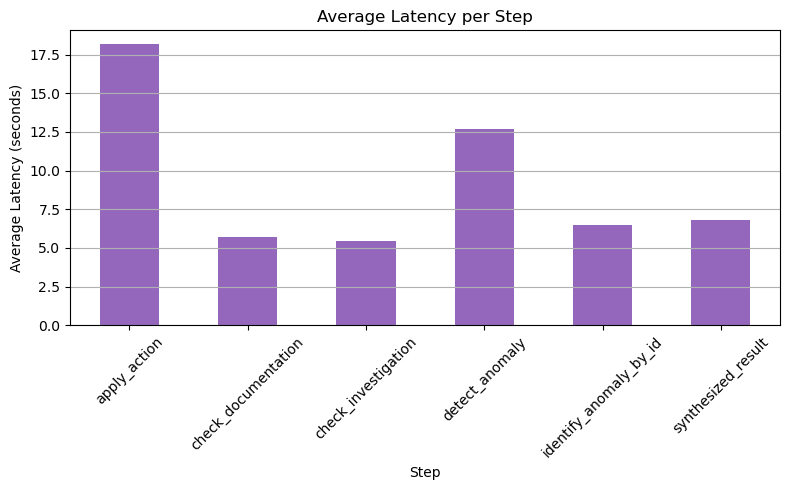

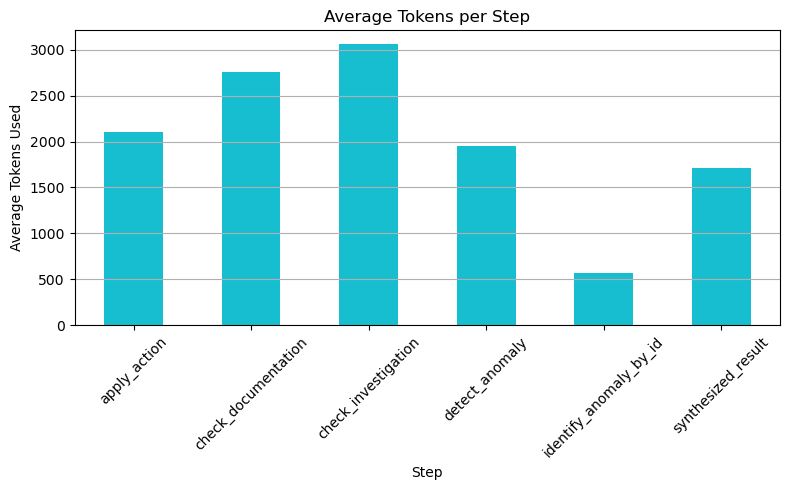

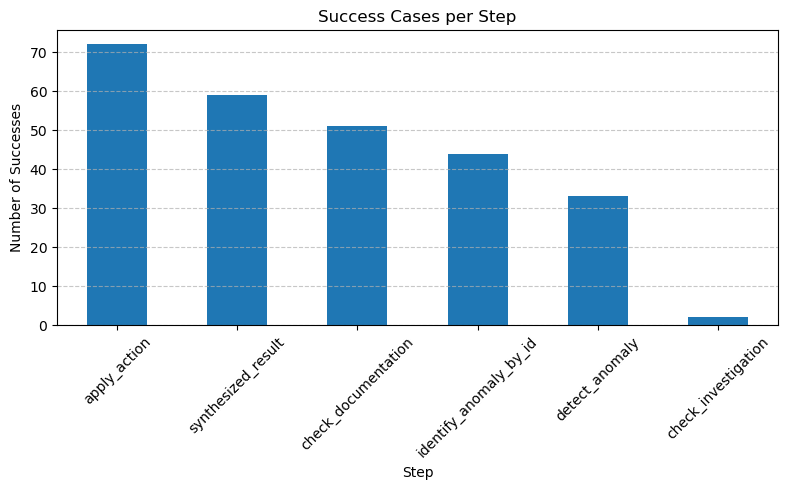

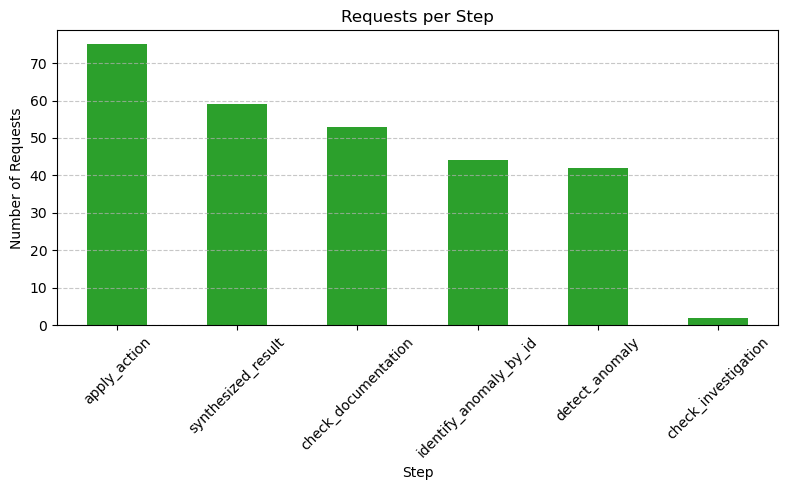

<Figure size 1000x600 with 0 Axes>

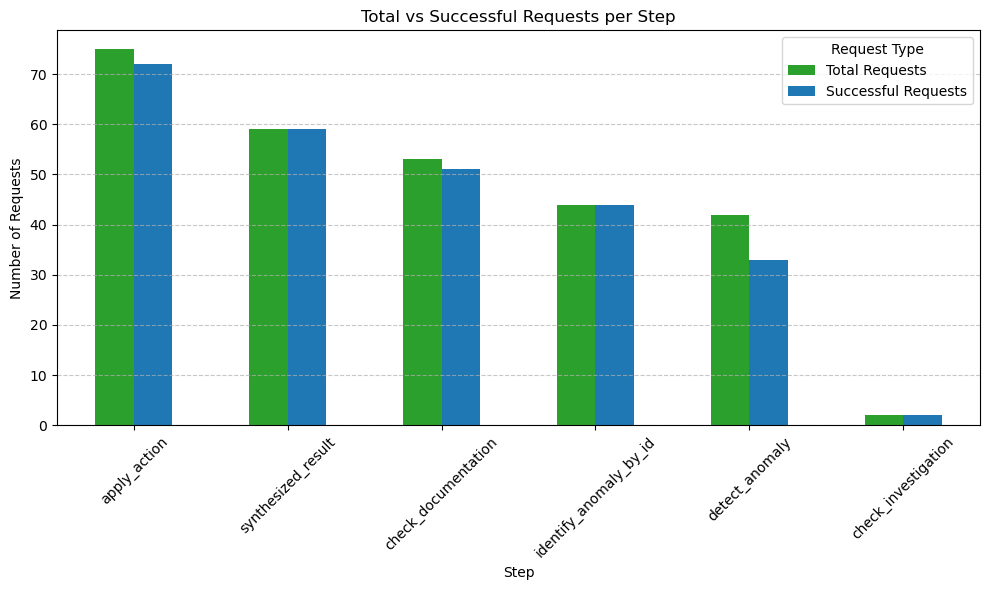

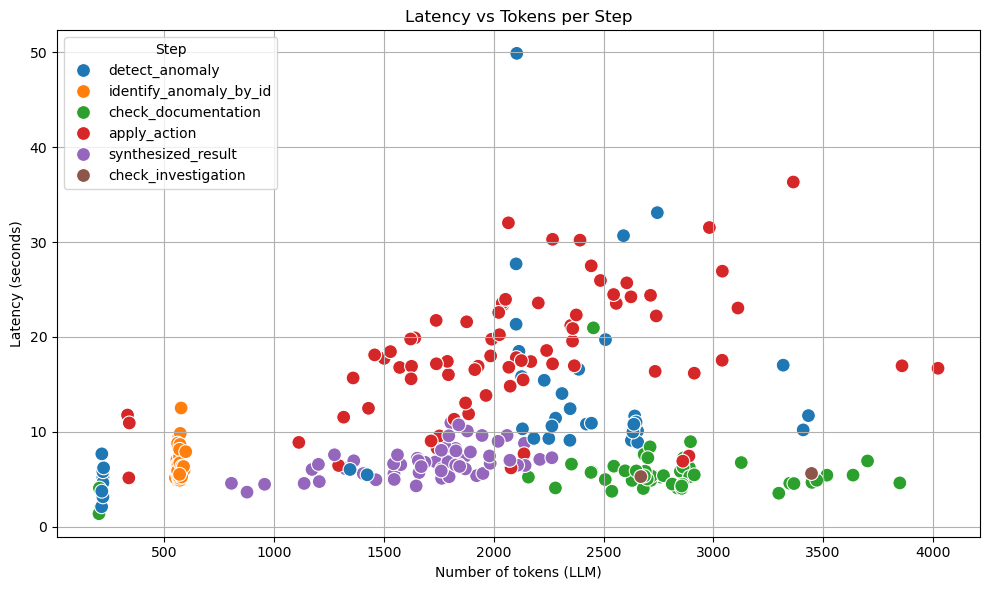

In [14]:

dark_palette = [
    "#1f77b4",  # dark blue
    "#ff7f0e",  # dark orange
    "#2ca02c",  # dark green
    "#d62728",  # dark red
    "#9467bd",  # dark purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf"   # cyan
]

report_metrics = rf.ReportFiles()
df = report_metrics.read_file_csv(reports_dir, report_metrics_file)


# Plot 1: Average Latency per Step
avg_latency_per_step = df.groupby("Step")["Latency"].mean()

plt.figure(figsize=(8, 5))
avg_latency_per_step.plot(kind="bar", color="#9467bd")
plt.title("Average Latency per Step")
plt.xlabel("Step")
plt.ylabel("Average Latency (seconds)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Plot 2: Average Tokens per Step
avg_tokens_per_step = df.groupby("Step")["Tokens"].mean()

plt.figure(figsize=(8, 5))
avg_tokens_per_step.plot(kind="bar", color="#17becf")
plt.title("Average Tokens per Step")
plt.xlabel("Step")
plt.ylabel("Average Tokens Used")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


# Count successful cases per step
success_counts = df[df['Success'] == True]['Step'].value_counts()

# Plotting
plt.figure(figsize=(8, 5))
success_counts.plot(kind='bar', color='#1f77b4')
plt.title('Success Cases per Step')
plt.xlabel('Step')
plt.ylabel('Number of Successes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Count successful cases per step
step_counts = df['Step'].value_counts()

# Plotting
plt.figure(figsize=(8, 5))
step_counts.plot(kind='bar', color='#2ca02c')
plt.title('Requests per Step')
plt.xlabel('Step')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Combine the counts into one DataFrame
combined = pd.DataFrame({
    'Total Requests': step_counts,
    'Successful Requests': success_counts
}).fillna(0).astype(int)

# Plotting
plt.figure(figsize=(10, 6))
combined.plot(kind='bar', figsize=(10, 6), color=['#2ca02c', '#1f77b4'])

# Chart formatting
plt.title('Total vs Successful Requests per Step')
plt.xlabel('Step')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title='Request Type')
plt.show()


# Plot: Latency vs Tokens colored by Step
plt.figure(figsize=(10, 6))
sns.set_palette(dark_palette)
sns.scatterplot(data=df, x="Tokens", y="Latency", hue="Step", s=100)

plt.title("Latency vs Tokens per Step")
plt.xlabel("Number of tokens (LLM)")
plt.ylabel("Latency (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()



